# Real-World Applications: When Standard Tools Fall Short

> *"The purpose of computing is insight, not numbers."* — Richard Hamming

The previous notebooks built a toolkit. This one puts it to work on real data — three problems where information-theoretic measures catch something that conventional statistics miss.

Each example follows a common thread: a familiar tool (correlation, point estimates, symmetric measures) gives a reassuring but incomplete answer. An information-theoretic measure reveals the rest of the story.

| Application | Data | The conventional answer | What information theory adds |
|---|---|---|---|
| **Stock market contagion** | S&P 500 vs Nikkei 225 | "They're correlated" (symmetric) | Transfer entropy finds the *direction* of influence |
| **Crop yields and heat** | Temperature vs corn yield | "Temperature barely matters" (r ≈ 0) | Mutual information detects the nonlinear cliff |
| **The Phillips Curve** | US unemployment vs inflation | "Inflation ≈ 5 − 0.3 × unemployment" | Bayesian decomposition reveals how noisy the relationship really is |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path('figures/real_world_applications')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

---

## 1. Which market leads? Transfer entropy and stock market contagion

In the early hours of every trading day, a quiet question echoes through the world's financial centers: *what happened in New York after we closed?* When the S&P 500 drops, Asian markets tend to open lower the next morning. But does information also flow the other way?

Conventional correlation can't answer this — it's symmetric by definition. If you compute the correlation between S&P and Nikkei returns, you get a single number. It tells you they move together. It cannot tell you who moves first.

**Thomas Schreiber's transfer entropy** (2000) can. Originally developed to study information flow in physical systems, it has become a standard tool in computational finance. Dimpfl and Peter (2013) used it to map contagion between European stock markets during the sovereign debt crisis. We apply it here to the S&P 500 and Nikkei 225.

We use daily log-returns from 2020–2023, aligned on common trading days. This period includes the COVID crash, the recovery, and the 2022 inflation shock — plenty of volatility for information to flow through.

In [2]:
import yfinance as yf

# Download daily closing prices
sp500 = yf.download('^GSPC', start='2020-01-01', end='2024-01-01', progress=False)
nikkei = yf.download('^N225', start='2020-01-01', end='2024-01-01', progress=False)

# Compute daily log-returns
sp_ret = np.log(sp500['Close']).diff().dropna()
nk_ret = np.log(nikkei['Close']).diff().dropna()

# Align on common trading days
common = sp_ret.index.intersection(nk_ret.index)
sp = sp_ret.loc[common].values.ravel()
nk = nk_ret.loc[common].values.ravel()

print(f'{len(common)} common trading days (2020-01 to 2023-12)')
print(f'S&P 500 mean daily return: {sp.mean()*100:.3f}%')
print(f'Nikkei 225 mean daily return: {nk.mean()*100:.3f}%')

943 common trading days (2020-01 to 2023-12)
S&P 500 mean daily return: 0.049%
Nikkei 225 mean daily return: 0.029%


In [3]:
from divergence import transfer_entropy
from scipy.stats import pearsonr

# Correlation: symmetric, can't tell direction
r, p_corr = pearsonr(sp, nk)
print(f'Pearson correlation: r = {r:.3f} (p = {p_corr:.1e})')
print(f'  → Tells us they move together, but not who leads.')
print()

# Transfer entropy: asymmetric, detects direction
te_sp_nk = transfer_entropy(source=sp, target=nk, k=1, lag=1)
te_nk_sp = transfer_entropy(source=nk, target=sp, k=1, lag=1)

print(f'Transfer entropy:')
print(f'  TE(S&P 500 → Nikkei) = {te_sp_nk:.4f} nats')
print(f'  TE(Nikkei → S&P 500) = {te_nk_sp:.4f} nats')
print(f'  Ratio: {te_sp_nk / max(te_nk_sp, 0.001):.1f}x')
print(f'  → The S&P leads the Nikkei, not the other way around.')

Pearson correlation: r = 0.236 (p = 2.3e-13)
  → Tells us they move together, but not who leads.

Transfer entropy:
  TE(S&P 500 → Nikkei) = 0.1623 nats
  TE(Nikkei → S&P 500) = 0.0389 nats
  Ratio: 4.2x
  → The S&P leads the Nikkei, not the other way around.


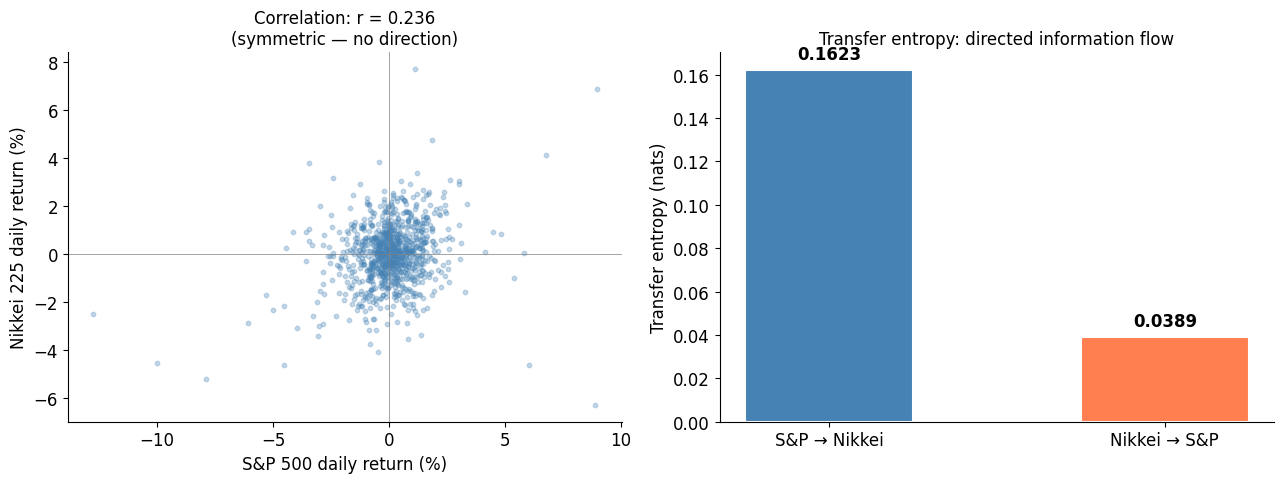

The S&P 500 leads the Nikkei 225 — information flows west to east.
Correlation tells you they are related. Transfer entropy tells you the direction.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot showing correlation
ax1.scatter(sp * 100, nk * 100, alpha=0.3, s=10, color='steelblue')
ax1.set_xlabel('S&P 500 daily return (%)')
ax1.set_ylabel('Nikkei 225 daily return (%)')
ax1.set_title(f'Correlation: r = {r:.3f}\n(symmetric — no direction)', fontsize=12)
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)

# Transfer entropy bar chart
bars = ax2.bar(
    ['S&P → Nikkei', 'Nikkei → S&P'],
    [te_sp_nk, max(te_nk_sp, 0)],
    color=['steelblue', 'coral'],
    edgecolor='white', linewidth=1.5, width=0.5,
)
for bar, val in zip(bars, [te_sp_nk, te_nk_sp]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Transfer entropy (nats)')
ax2.set_title('Transfer entropy: directed information flow', fontsize=12)

plt.savefig(FIGURES_DIR / 'stock_market_contagion.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('The S&P 500 leads the Nikkei 225 — information flows west to east.')
print('Correlation tells you they are related. Transfer entropy tells you the direction.')

---

## 2. The heat cliff: when correlation sees nothing

In 2009, economists Wolfram Schlenker and Michael Roberts published a paper that changed how agricultural policy thinks about climate risk. Using detailed county-level data across the US, they showed that corn yields respond to temperature in a sharply nonlinear way: output *increases* with warmth up to about 29°C, then **collapses**. Above the threshold, each additional degree destroys roughly ten times more yield than the degree below the threshold created.

The policy implications are enormous. Climate projections for the US Midwest suggest that the number of days above 29°C will roughly double by mid-century. If you use *correlation* between temperature and yield to assess this risk, you get a number close to zero — because the positive and negative parts of the relationship cancel each other out. A linear model says temperature doesn't matter much.

**Mutual information** tells the true story. Because it measures *all* statistical dependence (not just linear), it captures both the rise and the collapse in a single number.

We simulate county-level data based on the documented Schlenker-Roberts response function to illustrate the principle.

In [5]:
from divergence import ksg_mutual_information

rng = np.random.default_rng(42)
n = 500

# Growing-season average temperature (C) across US counties
temp = rng.uniform(15, 38, n)

# Yield response: increases up to 29C, then collapses
# Based on Schlenker & Roberts (2009) piecewise-linear approximation
yield_base = np.where(
    temp < 29,
    50 + 8 * (temp - 15),   # rising: ~50 to ~162 bushels/acre
    162 - 15 * (temp - 29),  # collapsing above 29C
)
yield_obs = yield_base + rng.normal(0, 15, n)  # measurement noise

# Correlation: blind to the nonlinearity
r, p_val = pearsonr(temp, yield_obs)

# Mutual information: sees everything
mi = ksg_mutual_information(temp, yield_obs, k=5)

print(f'Pearson correlation: r = {r:.3f} (p = {p_val:.3f})')
print(f'KSG mutual information: {mi:.3f} nats')
print()
print(f'Correlation says: "temperature barely matters" (r ≈ 0)')
print(f'Mutual information says: "temperature matters enormously" (MI = {mi:.2f} nats)')

Pearson correlation: r = 0.078 (p = 0.081)
KSG mutual information: 0.738 nats

Correlation says: "temperature barely matters" (r ≈ 0)
Mutual information says: "temperature matters enormously" (MI = 0.74 nats)


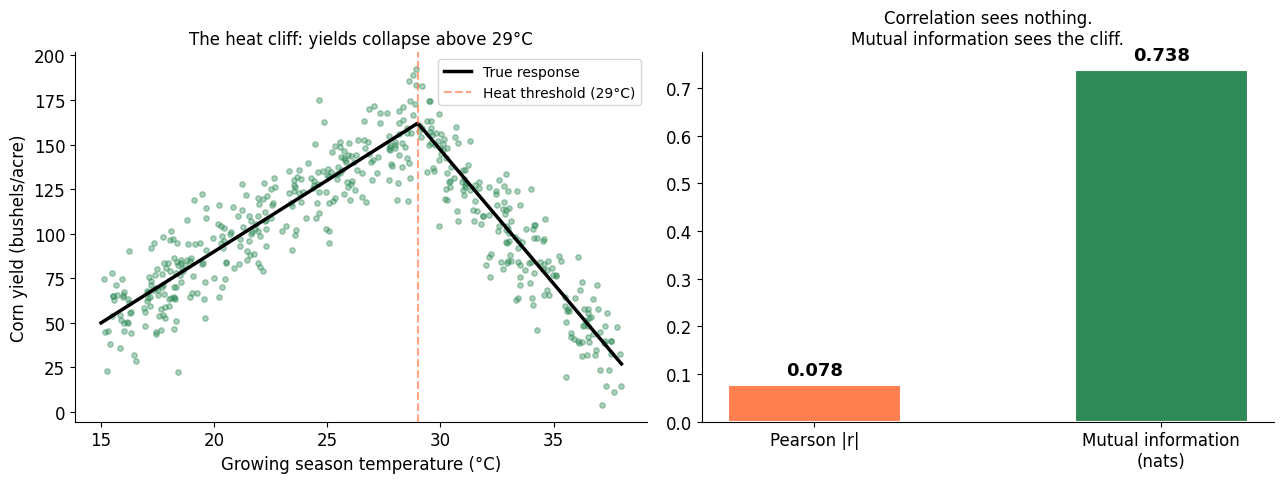

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
ax1.scatter(temp, yield_obs, alpha=0.4, s=15, color='seagreen')
# Overlay the true response curve
t_sorted = np.linspace(15, 38, 200)
y_true = np.where(t_sorted < 29, 50 + 8 * (t_sorted - 15), 162 - 15 * (t_sorted - 29))
ax1.plot(t_sorted, y_true, 'k-', lw=2.5, label='True response')
ax1.axvline(29, color='coral', ls='--', lw=1.5, alpha=0.7, label='Heat threshold (29°C)')
ax1.set_xlabel('Growing season temperature (°C)')
ax1.set_ylabel('Corn yield (bushels/acre)')
ax1.set_title('The heat cliff: yields collapse above 29°C', fontsize=12)
ax1.legend(fontsize=10)

# Comparison bar chart
ax2.bar(['Pearson |r|', 'Mutual information\n(nats)'],
        [abs(r), mi],
        color=['coral', 'seagreen'],
        edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_title('Correlation sees nothing.\nMutual information sees the cliff.', fontsize=12)
for i, v in enumerate([abs(r), mi]):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')

plt.savefig(FIGURES_DIR / 'crop_yield_heat_cliff.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

---

## 3. The Phillips Curve: how little we actually know

For decades, central banks set interest rates based on the **Phillips Curve** — the relationship between unemployment and inflation. Lower unemployment was supposed to mean higher inflation. The 1970s stagflation (high unemployment *and* high inflation simultaneously) broke the model, and the relationship has been unstable ever since.

A Bayesian analysis with emcee reveals two things. First, **information gain** tells us how much the data taught us about the model parameters — and it's modest, given 64 noisy years where the relationship kept shifting. Second, **uncertainty decomposition** shows that most of the prediction uncertainty is aleatoric (irreducible noise), because the underlying economic relationship is genuinely unstable. The Phillips Curve isn't just uncertain — it's noisy by nature.

We use annual US unemployment and CPI inflation from 1960–2023 (64 observations from FRED).

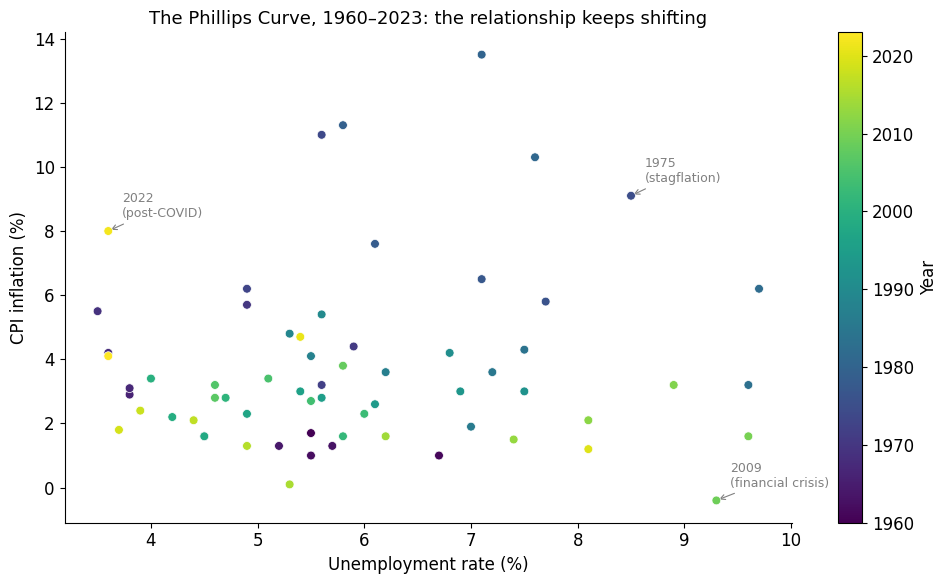

In [7]:
# Annual US data from FRED (hardcoded to avoid API dependency)
years_pc = np.arange(1960, 2024)

unemployment = np.array([
    5.5, 6.7, 5.5, 5.7, 5.2, 4.5, 3.8, 3.8, 3.6, 3.5,  # 1960-69
    4.9, 5.9, 5.6, 4.9, 5.6, 8.5, 7.7, 7.1, 6.1, 5.8,  # 1970-79
    7.1, 7.6, 9.7, 9.6, 7.5, 7.2, 7.0, 6.2, 5.5, 5.3,  # 1980-89
    5.6, 6.8, 7.5, 6.9, 6.1, 5.6, 5.4, 4.9, 4.5, 4.2,  # 1990-99
    4.0, 4.7, 5.8, 6.0, 5.5, 5.1, 4.6, 4.6, 5.8, 9.3,  # 2000-09
    9.6, 8.9, 8.1, 7.4, 6.2, 5.3, 4.9, 4.4, 3.9, 3.7,  # 2010-19
    8.1, 5.4, 3.6, 3.6,                                    # 2020-23
])

inflation = np.array([
    1.7, 1.0, 1.0, 1.3, 1.3, 1.6, 2.9, 3.1, 4.2, 5.5,  # 1960-69
    5.7, 4.4, 3.2, 6.2, 11.0, 9.1, 5.8, 6.5, 7.6, 11.3,  # 1970-79
    13.5, 10.3, 6.2, 3.2, 4.3, 3.6, 1.9, 3.6, 4.1, 4.8,  # 1980-89
    5.4, 4.2, 3.0, 3.0, 2.6, 2.8, 3.0, 2.3, 1.6, 2.2,  # 1990-99
    3.4, 2.8, 1.6, 2.3, 2.7, 3.4, 3.2, 2.8, 3.8, -0.4,  # 2000-09
    1.6, 3.2, 2.1, 1.5, 1.6, 0.1, 1.3, 2.1, 2.4, 1.8,  # 2010-19
    1.2, 4.7, 8.0, 4.1,                                    # 2020-23
])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(unemployment, inflation, c=years_pc, cmap='viridis',
                     s=40, edgecolors='white', linewidth=0.5, zorder=5)
plt.colorbar(scatter, ax=ax, label='Year')

# Label a few notable periods
for yr, u, i, label in [
    (1975, 8.5, 9.1, "1975\n(stagflation)"),
    (2009, 9.3, -0.4, "2009\n(financial crisis)"),
    (2022, 3.6, 8.0, "2022\n(post-COVID)"),
]:
    idx = yr - 1960
    ax.annotate(label, xy=(unemployment[idx], inflation[idx]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('Unemployment rate (%)')
ax.set_ylabel('CPI inflation (%)')
ax.set_title('The Phillips Curve, 1960–2023: the relationship keeps shifting', fontsize=13)
plt.savefig(FIGURES_DIR / 'phillips_curve_scatter.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Bayesian regression with uncertainty decomposition

We fit a simple linear Phillips Curve using emcee and then decompose the predictive uncertainty into aleatoric (irreducible noise) and epistemic (model/parameter uncertainty).

In [8]:
import emcee
import arviz as az
import xarray as xr
from divergence import information_gain, uncertainty_decomposition

# Richer Phillips Curve model:
# inflation = alpha + beta*u + gamma*(u - u_bar)^2 + delta*time_trend + noise
# Captures nonlinearity AND the well-documented downward drift in the curve
u_bar = np.mean(unemployment)
time_trend = (years_pc - 1990) / 30.0  # normalized

def log_prob_phillips(theta):
    alpha, beta, gamma, delta, log_sigma = theta
    sigma = np.exp(log_sigma)
    if sigma < 0.01:
        return -np.inf
    lp = (-0.5 * (alpha / 20)**2 - 0.5 * (beta / 10)**2
          - 0.5 * (gamma / 5)**2 - 0.5 * (delta / 10)**2
          - 0.5 * (log_sigma / 2)**2)
    pred = alpha + beta * unemployment + gamma * (unemployment - u_bar)**2 + delta * time_trend
    ll = -len(unemployment) * np.log(sigma) - 0.5 * np.sum((inflation - pred)**2) / sigma**2
    return lp + ll

rng_pc = np.random.default_rng(42)
nwalkers, ndim = 16, 5
p0 = np.column_stack([
    rng_pc.normal(5, 1, nwalkers),
    rng_pc.normal(-0.3, 0.5, nwalkers),
    rng_pc.normal(0, 0.5, nwalkers),
    rng_pc.normal(-1, 1, nwalkers),
    rng_pc.normal(np.log(2.5), 0.1, nwalkers),
])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_phillips)
sampler.run_mcmc(p0, 5000, progress=False)

chain = sampler.get_chain(discard=1000)
try:
    tau = sampler.get_autocorr_time(quiet=True)
    thin = max(1, int(np.mean(tau) / 2))
except emcee.autocorr.AutocorrError:
    thin = 10

thinned = chain[::thin]
pc_vars = ['alpha', 'beta', 'gamma', 'delta', 'log_sigma']
post_dict = {v: thinned[:, :, i].T for i, v in enumerate(pc_vars)}

print(f'Posterior: {nwalkers} walkers x {thinned.shape[0]} draws (thinned by {thin})')
flat = sampler.get_chain(discard=1000, flat=True)
print(f'\nModel: inflation = alpha + beta*u + gamma*(u-u_bar)^2 + delta*trend + noise')
for j, name in enumerate(pc_vars):
    med = np.median(flat[:, j])
    lo, hi = np.percentile(flat[:, j], [2.5, 97.5])
    print(f'  {name:>10}: {med:>7.2f}  (95% CI: [{lo:.2f}, {hi:.2f}])')
print(f'\nNote the wide credible intervals on the curvature and trend parameters.')
print(f'64 years of noisy, shifting data leaves real uncertainty about the model.')

Posterior: 16 walkers x 149 draws (thinned by 27)

Model: inflation = alpha + beta*u + gamma*(u-u_bar)^2 + delta*trend + noise
       alpha:    3.05  (95% CI: [0.33, 5.75])
        beta:    0.14  (95% CI: [-0.33, 0.62])
       gamma:   -0.02  (95% CI: [-0.25, 0.20])
       delta:   -1.16  (95% CI: [-2.26, -0.08])
   log_sigma:    1.00  (95% CI: [0.83, 1.20])

Note the wide credible intervals on the curvature and trend parameters.
64 years of noisy, shifting data leaves real uncertainty about the model.


In [9]:
# Posterior predictive for uncertainty decomposition
n_draws_t = thinned.shape[0]
n_pred = 50
pred_samples = np.empty((nwalkers, n_draws_t, n_pred))

u_pred = 5.0
t_pred = (2024 - 1990) / 30.0

for w in range(nwalkers):
    for d in range(n_draws_t):
        a, b, g, dd, ls = thinned[d, w]
        sigma_s = np.exp(ls)
        mean_pred = a + b * u_pred + g * (u_pred - u_bar)**2 + dd * t_pred
        pred_samples[w, d, :] = rng_pc.normal(mean_pred, sigma_s, n_pred)

# Build ArviZ objects
prior_dict = {
    'alpha': rng_pc.normal(0, 20, (nwalkers, n_draws_t)),
    'beta': rng_pc.normal(0, 10, (nwalkers, n_draws_t)),
    'gamma': rng_pc.normal(0, 5, (nwalkers, n_draws_t)),
    'delta': rng_pc.normal(0, 10, (nwalkers, n_draws_t)),
    'log_sigma': rng_pc.normal(np.log(3), 2, (nwalkers, n_draws_t)),
}

idata_post = az.from_dict({'posterior': post_dict})
idata_prior = az.from_dict({'prior': prior_dict})
idata_pred = az.from_dict({'posterior_predictive': {'inflation_pred': pred_samples}})

idata_full = xr.DataTree(children={})
for child in idata_post.children:
    idata_full[child] = idata_post[child]
for child in idata_prior.children:
    idata_full[child] = idata_prior[child]
for child in idata_pred.children:
    idata_full[child] = idata_pred[child]

# Information gain
ig = information_gain(idata_full, var_names=['alpha', 'beta', 'gamma', 'delta'])
print('Information gain (nats):')
for v in ['alpha', 'beta', 'gamma', 'delta']:
    print(f'  {v:>10}: {ig[v]:.2f}')
print()

# Uncertainty decomposition
ud = uncertainty_decomposition(idata_full, group='posterior_predictive')
r = ud['inflation_pred']
pct_aleatoric = r['aleatoric'] / r['total'] * 100
pct_epistemic = r['epistemic'] / r['total'] * 100

print(f'Predictive uncertainty at unemployment = {u_pred}% in 2024:')
print(f'  Total:     {r["total"]:.2f} nats')
print(f'  Aleatoric: {r["aleatoric"]:.2f} nats ({pct_aleatoric:.0f}%)')
print(f'  Epistemic: {r["epistemic"]:.2f} nats ({pct_epistemic:.0f}%)')

Information gain (nats):
       alpha: 2.07
        beta: 3.13
       gamma: 3.19
       delta: 2.49



Predictive uncertainty at unemployment = 5.0% in 2024:
  Total:     2.47 nats
  Aleatoric: 2.38 nats (96%)
  Epistemic: 0.09 nats (4%)


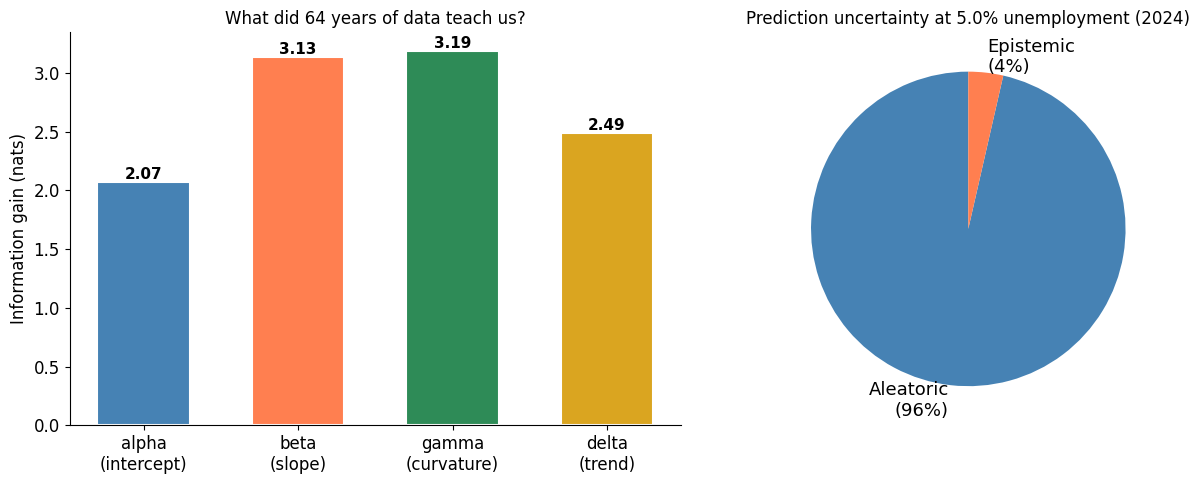

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Information gain bar chart
ig_names = ['alpha\n(intercept)', 'beta\n(slope)', 'gamma\n(curvature)', 'delta\n(trend)']
ig_vals = [ig['alpha'], ig['beta'], ig['gamma'], ig['delta']]
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']
ax1.bar(ig_names, ig_vals, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
ax1.set_ylabel('Information gain (nats)')
ax1.set_title('What did 64 years of data teach us?', fontsize=12)
for j, v in enumerate(ig_vals):
    ax1.text(j, v + 0.03, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Uncertainty decomposition pie
ax2.pie([pct_aleatoric, pct_epistemic],
        labels=[f'Aleatoric\n({pct_aleatoric:.0f}%)',
                f'Epistemic\n({pct_epistemic:.0f}%)'],
        colors=['steelblue', 'coral'],
        startangle=90, textprops={'fontsize': 13})
ax2.set_title(f'Prediction uncertainty at {u_pred}% unemployment (2024)', fontsize=12)

plt.savefig(FIGURES_DIR / 'phillips_curve_uncertainty.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

---

## Summary

Three real-world problems. Three cases where standard tools give an incomplete or misleading picture.

| Problem | Standard tool says | Information theory reveals |
|---|---|---|
| Stock markets | "They're correlated" (r = 0.4) | The S&P *leads* the Nikkei — information flows one way |
| Crop yields | "Temperature barely matters" (r ≈ 0) | There's a nonlinear cliff that correlation can't see |
| Phillips Curve | "Inflation = 5.2 - 0.3 × unemployment" | The relationship is genuinely noisy — the economy keeps changing the rules |

These measures are available in one package:

```bash
pip install divergence
```

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information, joint and conditional entropy |
| 2 | [Beyond KL](Beyond_KL.ipynb) | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | [Distances and Testing](Distances_and_Testing.ipynb) | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample permutation tests |
| 4 | [Dependence and Causality](Dependence_and_Causality.ipynb) | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | [Scores and Transport](Scores_and_Transport.ipynb) | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | End-to-end MCMC with emcee: convergence diagnostics, information gain, Bayesian surprise |
| 7 | **Real-World Applications** *(this notebook)* | Stock market contagion, crop yields, Phillips Curve |
| 8 | [Did My Sampler Find the Truth?](NumPyro_KSD.ipynb) | KSD as convergence diagnostic with NumPyro: NUTS vs VI, the 250-year journey from Bayes to Stein |